# Your own function, your own derivative

Write a function with a derivative YOU supply, and prove hawk really
uses it.

**Time:** ~7 min &middot; **Runs on:** CPU (same code on GPU) &middot;
**You need:** [extend it by inheritance](02_extend_by_inheritance)

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "_shared"))
from nb_helpers import plot_style
plot_style()


## The vocabulary, reused

`Perturbed` is the same `Kind` the last tutorial built:

In [2]:
import hawk
from hawk import Mutable, Param, Scalar, Vector
from hawk.ext import DATA_ONLY, KernelKind


class Orbit(KernelKind, slug="orbit"):
    r: Vector[3]
    v: Vector[3]
    dt: Param
    g: Param
    guard = DATA_ONLY


class Perturbed(Orbit, slug="perturbed"):
    cd: Scalar

## A primitive: your own forward, your own rules

`hawk.ext.primitive(name, vjp=..., jvp=...)` registers a plain Python
function that gets inlined everywhere it is CALLED INSIDE A KERNEL, plus
a reverse (`vjp`) and/or forward (`jvp`) derivative rule you supply — the
derivative table's own rule for that arithmetic is never consulted.
`speed_ramp` smoothly turns a force on past a threshold speed; its exact
derivative, by hand, is the logistic sigmoid `1 / (1 + exp(-s))` —
exactly what both lambdas below compute (the finite-difference check
later on this page confirms it numerically):

In [3]:
from hawk.ext import primitive
from hawk.math import exp, log


@primitive("speed_ramp",
           vjp=lambda s, bar: bar / (1.0 + exp(-s)),
           jvp=lambda s, ds: ds / (1.0 + exp(-s)))
def speed_ramp(s):
    return log(1.0 + exp(s))

## A kernel that uses it

`eased_drag` is the drag family from the last tutorial, but the
quadratic term ramps on smoothly past `v_crit` instead of applying in
full from `v=0`. It only reads `v` and `cd` from `Perturbed`'s
vocabulary — a kernel is never required to use every name its `Kind`
declares, only the ones its own body needs:

In [4]:
import numpy as np
from hawk.math import norm


@Perturbed
def eased_drag(v, cd, v_crit: Param, a_mag: Mutable[Scalar]):
    a_mag = cd * speed_ramp(norm(v) - v_crit)


eased_drag


<Kernel eased_drag slots=4>

`hawk.artifact.build` + `hawk.load`/`hawk.run` build and run it on the host:


In [5]:
import pathlib, tempfile

import hawk.artifact

work_dir = pathlib.Path(tempfile.mkdtemp())
speeds = np.linspace(0.0, 40.0, 6)
v = np.zeros((3, 6)); v[0] = speeds
a_mag = np.zeros(6)
hawk.artifact.build(eased_drag, work_dir, targets=("host",))
eased_drag_host = hawk.load(work_dir, "eased_drag")
hawk.run(eased_drag_host, v=v, cd=np.full(6, 0.004), v_crit=25.0, a_mag=a_mag)
drag_by_speed = dict(zip(speeds.tolist(), a_mag.round(4).tolist()))
print("drag magnitude by speed:", drag_by_speed)


drag magnitude by speed: {0.0: 0.0, 8.0: 0.0, 16.0: 0.0, 24.0: 0.0013, 32.0: 0.028, 40.0: 0.06}


## Proving the SUPPLIED rule is the one used

A correct derivative is not enough proof: the table's own rule for
`log(1 + exp(s))` is ALSO correct, so a right answer alone cannot tell you
which one ran. Declare the derivative deliberately wrong -- three times too
big -- and check that the wrong number comes out:

In [6]:
from hawk import Kernel
from hawk.diff import vjp


@primitive("deliberately_wrong", vjp=lambda s, bar: 3.0 * bar)
def deliberately_wrong(s):
    return s + 0.0          # the identity -- its TRUE gradient is 1, not 3


@hawk.kernel
def control(x: Scalar, y: Mutable[Scalar]):
    y = deliberately_wrong(x)


control_vjp = Kernel("control_vjp", vjp(control, wrt=("x",)))


In [7]:
hawk.build([control, control_vjp], work_dir, targets=("host",))
bar_x = np.zeros(2)
hawk.run(hawk.load(work_dir, "control_vjp"), x=np.array([1.0, 2.0]),
       bar_y=np.array([1.0, 1.0]), bar_x=bar_x)
print("gradient (expect 3, not 1):", bar_x)


gradient (expect 3, not 1): [3. 3.]


`deliberately_wrong`'s TRUE derivative is 1 (it is the identity); the
declared rule said 3, and 3 is what came back. If hawk had differentiated
THROUGH the inlined forward instead of applying the supplied rule, this
would print `[1. 1.]` -- proof the rule you write is the one that runs, not
a decoration beside the real derivative.

`speed_ramp`'s own rule is correct, not a deliberate trick -- check it
against a finite difference:

In [8]:
@hawk.kernel
def ramp_only(x: Scalar, y: Mutable[Scalar]):
    y = speed_ramp(x)


ramp_only_vjp = Kernel("ramp_only_vjp", vjp(ramp_only, wrt=("x",)))
hawk.build([ramp_only, ramp_only_vjp], work_dir, targets=("host",));


Run it, and check the supplied rule against a finite difference:


In [9]:
xs = np.linspace(-6.0, 6.0, 25)
H = 1e-5
y_plus, y_minus = np.zeros(25), np.zeros(25)
ramp_host = hawk.load(work_dir, "ramp_only")
hawk.run(ramp_host, x=xs + H, y=y_plus)
hawk.run(ramp_host, x=xs - H, y=y_minus)
fd = (y_plus - y_minus) / (2 * H)

bar_x = np.zeros(25)
hawk.run(hawk.load(work_dir, "ramp_only_vjp"), x=xs, bar_y=np.ones(25), bar_x=bar_x)
print("max|supplied vjp - central difference|:", np.max(np.abs(fd - bar_x)))


max|supplied vjp - central difference|: 5.410094594537895e-11


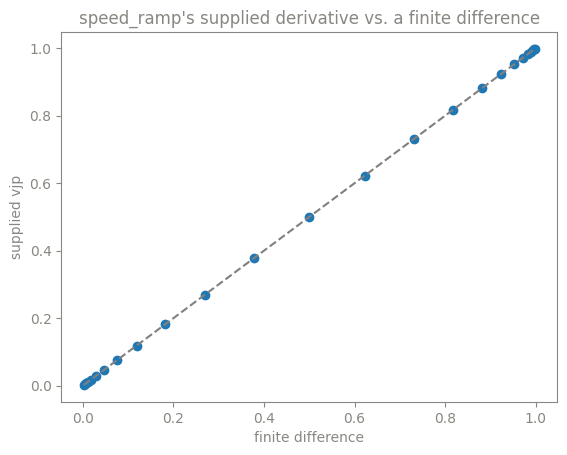

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(fd, bar_x, "o")
lims = [fd.min(), fd.max()]
ax.plot(lims, lims, "--", color="gray")
ax.set_xlabel("finite difference"); ax.set_ylabel("supplied vjp")
ax.set_title("speed_ramp's supplied derivative vs. a finite difference")
plt.show()

## Differentiating a Kind-built kernel

Everything above differentiated a plain `@hawk.kernel`. `vjp` works
exactly the same way on a kernel built from a `Kind` — here, `eased_drag`
itself, your vocabulary and your primitive, differentiated with respect
to `cd`:

In [11]:
eased_drag_vjp = Kernel("eased_drag_vjp", vjp(eased_drag, wrt=("cd",)))
hawk.artifact.build(eased_drag_vjp, work_dir, targets=("host",));


Run it, and check against a finite difference of `eased_drag` itself:


In [12]:
bar_a_mag = np.ones(6)
bar_cd = np.zeros(6)
hawk.run(hawk.load(work_dir, "eased_drag_vjp"), v=v, cd=np.full(6, 0.004), v_crit=25.0,
       bar_a_mag=bar_a_mag, bar_cd=bar_cd)

H = 1e-6
a_plus, a_minus = np.zeros(6), np.zeros(6)
hawk.run(eased_drag_host, v=v, cd=np.full(6, 0.004 + H), v_crit=25.0, a_mag=a_plus)
hawk.run(eased_drag_host, v=v, cd=np.full(6, 0.004 - H), v_crit=25.0, a_mag=a_minus)
fd_cd = (a_plus - a_minus) / (2 * H)
diff_cd = np.max(np.abs(bar_cd - fd_cd))
print("max|d(a_mag)/d(cd), supplied - central difference|:", diff_cd)


max|d(a_mag)/d(cd), supplied - central difference|: 3.4567904094728874e-12


Your `Kind`, your primitive, and `hawk.diff` are the same three pieces
the [capstone](04_capstone) runs at scale — this is that whole chain in
ten lines.

## What just happened

- `@primitive(name, vjp=..., jvp=...)` registers a forward that is INLINED
  everywhere it is called, plus the derivative rule(s) that replace the
  table's for that subgraph.
- A deliberately wrong rule proves the point: the SUPPLIED rule is what
  runs, not the table's correct rule for the same arithmetic.
- `speed_ramp`'s own rule lands exactly on the finite-difference line, and
  so does `vjp` applied directly to a `Kind`-built kernel like `eased_drag`
  — differentiation does not care whether a kernel came from a plain
  `@hawk.kernel` or a vocabulary.

## Try this

Register a second primitive with only a `vjp=` (no `jvp=`), use it in a
kernel, then call `hawk.diff.jvp` on that kernel -- hawk refuses by name
rather than falling back to the table.

## Next

[Capstone: your physics, end to end](04_capstone) -- the same `Kind` and the
same primitive, run at scale and handed to PyTorch. Not ready for a
primitive, or need raw C++ instead? See
[when hawk can't spell it](when_hawk_cant_spell_it).